# 06. Sampling, Measurement, and Data Collection Bias

A dataset can be large, cleanly formatted, and still systematically misleading. The problem is not always in the estimator. Often it is in the data pipeline itself. Who made it into the file? Which tickets were never logged? Who responded to the survey? Which variables were measured poorly at intake? These questions belong to statistics before they belong to machine learning or causal inference.

We study sampling bias, measurement error, and data-collection bias in a seller-support workflow. We will simulate a full population of tickets, then generate several imperfect operational data sources from it: a dashboard feed with selective coverage, a post-interaction survey with differential response, and intake labels with measurement error. The goal is to show that a biased data stream can produce a biased answer even when all downstream calculations are technically correct.


## Learning Objectives

By the end of this lecture, you should be able to:

1. Explain the difference between random sampling error and systematic bias.
2. Distinguish coverage bias, nonresponse bias, and measurement error in a practical workflow.
3. Show how convenience samples can remain wrong even when they are large.
4. Explain how outcome-dependent response behavior can distort survey-based conclusions.
5. Diagnose how label noise or intake misclassification changes group summaries.
6. Compare multiple operational data sources against a population benchmark in a simulation setting.
7. Translate bias diagnostics into a professional recommendation about dataset credibility.


## Mathematical Core: What Bias Means Before Modeling

Let the target population distribution be `P`, and let `Y` be the quantity we wish to learn about, such as true service time or true satisfaction. The population estimand might be

$$
\mu = E_P[Y].
$$

If the observed dataset is generated by a sampling or logging process `S = 1`, the sample usually estimates a different quantity:

$$
E[Y \mid S = 1].
$$

Sampling bias appears when these two are not the same:

$$
Bias(\bar Y_S) = E[\bar Y_S] - \mu.
$$

A sufficient warning sign is that inclusion depends on variables related to the outcome:

$$
P(S=1 \mid Y, X) \ne P(S=1 \mid X).
$$

Measurement error creates another layer. If the recorded variable is

$$
Y^{obs} = Y + \eta,
$$

then even a representative sample may estimate properties of `Y^{obs}` in place of `Y`. If the error `eta` is systematic and directional, averages, rates, correlations, and model coefficients can all move in the wrong direction.

The key lesson for the simulations below is this: more rows reduce variance, but they do not automatically remove sampling bias, nonresponse bias, or measurement bias.

In [1]:
# Load the libraries and notebook settings used in the examples below.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.float_format", "{:.3f}".format)
pd.set_option("display.max_columns", 24)

from pathlib import Path
import sys


def _find_project_root(start=Path.cwd()):
    """
    Locate the portfolio root so shared notebook helpers import reliably.
    
    Parameters:
        start: Starting path for the upward project-root search.
    
    Returns:
        A `Path` pointing to the nearest portfolio root that contains `notebooks/_shared`; if no such parent is found, the original starting path is returned.
    """

    for candidate in [start, *start.parents]:
        if (candidate / "notebooks" / "_shared").exists():
            return candidate
    return start


PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from notebooks._shared.display import smart_display

## 1. Bias Enters Before Estimation Begins

A common misconception is that statistical trouble starts only when the wrong model is fit. In practice, the trouble often starts earlier.

If hard tickets are under-logged, the dashboard will look too healthy. If dissatisfied sellers are more likely to answer a survey, the survey will look too negative. If urgency is misclassified at intake, group-specific risk summaries will be diluted. None of these failures is fixed by using a fancier estimator on the same flawed data.


| Bias Type | What Goes Wrong | Typical Operational Example |
|---|---|---|
| Coverage bias | The observed frame omits some parts of the target population | Overnight or phone tickets fail to enter the dashboard reliably |
| Convenience sampling bias | The analyst studies whichever data are easiest to export | Only logged tickets or only one region are analyzed |
| Nonresponse bias | Some units are less likely to provide a measurement | Dissatisfied sellers are more likely to answer feedback surveys |
| Measurement error | A recorded variable differs from the true value | Intake severity is misclassified or satisfaction is misreported |
| Total data-collection bias | Multiple upstream distortions combine | Logged data, survey data, and labels all tilt in different directions |


The distinction between variance and bias matters here. Random sampling error makes estimates noisy around the truth. Systematic bias shifts estimates away from the truth on average. Increasing sample size reduces the first problem, but it does not automatically fix the second.

This is why large datasets can still produce confidently wrong answers. If the frame is distorted or the measurement is flawed, scale only gives us a sharper picture of the distortion.

## 2. Simulating a Population and Several Imperfect Data Sources

We start with a full ticket population. This is the hidden ground truth available only because we are in a simulation. From that population we generate three imperfect data sources:

1. a dashboard frame that undercaptures overnight, phone, and urgent tickets;
2. a survey-response sample in which dissatisfied sellers are more likely to reply;
3. an observed intake severity label that is noisy relative to the true severity.

### Dataset and Experiment Design

Each row in the full population is a support ticket with true severity, channel, arrival timing, seller tier, response outcome, satisfaction, and SLA status. The analysis then creates alternative observed datasets from that same population. One dataset is distorted by coverage, one by response behavior, and one by measurement error.

The experiment asks how the same business question changes when the data source changes. We compare random audits, dashboard exports, survey respondents, and noisy labels against the hidden truth. This lets the notebook separate three common problems that are often blended together in practice: who enters the dataset, who responds after being asked, and how accurately the recorded variables measure the intended concepts.

In [2]:
# Define helper functions and reusable utilities for this section.
rng = np.random.default_rng(2036)

def sigmoid(x):
    """
    Transform a linear score into a probability with the logistic function.
    
    Parameters:
        x: Input value or array passed to the mathematical transform.
    
    Returns:
        A scalar or NumPy array containing the logistic transform of `x`, useful for converting linear scores into probabilities.
    
    Idea:
        Convert additive risk drivers into bounded probabilities, allowing synthetic event rates to respond smoothly to covariates.
    """
    return 1.0 / (1.0 + np.exp(-x))


n_tickets = 120_000
seller_tier_levels = np.array(["standard", "growth", "enterprise"])
severity_levels = ["low", "medium", "high", "urgent"]
channel_levels = np.array(["chat", "email", "phone"])
region_levels = np.array(["North", "South", "West", "Central"])

seller_tier = rng.choice(seller_tier_levels, size=n_tickets, p=[0.61, 0.25, 0.14])
region = rng.choice(region_levels, size=n_tickets, p=[0.26, 0.24, 0.29, 0.21])
priority_contract = (
    (seller_tier == "enterprise")
    | ((seller_tier == "growth") & (rng.random(n_tickets) < 0.36))
).astype(int)

latent_complexity = rng.normal(
    loc=-0.16
    + 0.18 * (seller_tier == "growth")
    + 0.42 * (seller_tier == "enterprise")
    + 0.10 * (region == "West"),
    scale=0.82,
    size=n_tickets,
)

severity_score = latent_complexity + 0.18 * priority_contract + rng.normal(0, 0.90, size=n_tickets)
true_severity = pd.cut(
    severity_score,
    bins=[-np.inf, -0.55, 0.35, 1.05, np.inf],
    labels=severity_levels,
)
true_severity = pd.Categorical(true_severity, categories=severity_levels, ordered=True)

channel_probability_map = {
    "low": [0.64, 0.27, 0.09],
    "medium": [0.46, 0.35, 0.19],
    "high": [0.27, 0.37, 0.36],
    "urgent": [0.09, 0.31, 0.60],
}

channel = np.empty(n_tickets, dtype=object)
for sev, probs in channel_probability_map.items():
    mask = true_severity == sev
    channel[mask] = rng.choice(channel_levels, size=mask.sum(), p=probs)

overnight_prob = sigmoid(
    -2.10
    + 0.62 * (true_severity == "urgent").astype(float)
    + 0.24 * (channel == "phone").astype(float)
    + 0.18 * (region == "West").astype(float)
)
overnight = rng.binomial(1, overnight_prob)

repeat_contact_prob = sigmoid(
    -1.30
    + 0.36 * (true_severity == "high").astype(float)
    + 0.72 * (true_severity == "urgent").astype(float)
    + 0.24 * priority_contract
)
repeat_contact = rng.binomial(1, repeat_contact_prob)

queue_load = rng.normal(
    loc=-0.08
    + 0.22 * (true_severity == "high").astype(float)
    + 0.52 * (true_severity == "urgent").astype(float)
    + 0.32 * overnight,
    scale=0.78,
    size=n_tickets,
)
queue_load = np.clip(queue_load, -2.2, 3.2)

response_log = (
    1.92
    + np.select(
        [true_severity == "low", true_severity == "medium", true_severity == "high", true_severity == "urgent"],
        [-0.25, 0.00, 0.43, 0.82],
    )
    + 0.28 * queue_load
    + 0.20 * overnight
    + 0.11 * (channel == "phone").astype(float)
    + 0.15 * repeat_contact
    + rng.normal(0, 0.34, size=n_tickets)
)
true_response_minutes = np.exp(response_log)
true_breach = (true_response_minutes > 15).astype(int)

true_satisfaction_latent = (
    4.90
    - 0.060 * true_response_minutes
    - 0.20 * repeat_contact
    - 0.25 * (true_severity == "high").astype(float)
    - 0.55 * (true_severity == "urgent").astype(float)
    + 0.12 * priority_contract
    + rng.normal(0, 0.42, size=n_tickets)
)
true_satisfaction_score = np.clip(true_satisfaction_latent, 1, 5)
true_dissatisfied = (true_satisfaction_score <= 2.4).astype(int)

dashboard_logged_prob = sigmoid(
    2.20
    - 1.15 * (channel == "phone").astype(float)
    - 1.00 * overnight
    - 0.72 * (true_severity == "urgent").astype(float)
    - 0.22 * (true_severity == "high").astype(float)
    + 0.24 * priority_contract
)
dashboard_logged = rng.binomial(1, dashboard_logged_prob)

survey_response_prob = sigmoid(
    -2.65
    + 1.00 * true_dissatisfied
    + 0.35 * priority_contract
    + 0.18 * (true_response_minutes < 8).astype(float)
)
survey_responded = rng.binomial(1, survey_response_prob)

observed_satisfaction_score = np.clip(
    np.round(true_satisfaction_score + rng.normal(0, 0.45, size=n_tickets)),
    1,
    5,
)
observed_satisfaction_score = np.where(survey_responded == 1, observed_satisfaction_score, np.nan)

severity_confusion_map = {
    "low": [0.88, 0.10, 0.02, 0.00],
    "medium": [0.08, 0.74, 0.16, 0.02],
    "high": [0.02, 0.16, 0.70, 0.12],
    "urgent": [0.00, 0.08, 0.24, 0.68],
}

observed_severity = np.empty(n_tickets, dtype=object)
for sev, probs in severity_confusion_map.items():
    mask = true_severity == sev
    observed_severity[mask] = rng.choice(severity_levels, size=mask.sum(), p=probs)
observed_severity = pd.Categorical(observed_severity, categories=severity_levels, ordered=True)

population = pd.DataFrame(
    {
        "seller_tier": seller_tier,
        "region": region,
        "priority_contract": priority_contract,
        "true_severity": true_severity,
        "observed_severity": observed_severity,
        "channel": channel,
        "overnight": overnight,
        "repeat_contact": repeat_contact,
        "queue_load": queue_load,
        "true_response_minutes": true_response_minutes,
        "true_breach": true_breach,
        "true_satisfaction_score": true_satisfaction_score,
        "true_dissatisfied": true_dissatisfied,
        "dashboard_logged": dashboard_logged,
        "survey_responded": survey_responded,
        "observed_satisfaction_score": observed_satisfaction_score,
    }
)

dashboard_frame = population.loc[population["dashboard_logged"] == 1].copy()
survey_frame = population.loc[population["survey_responded"] == 1].copy()
audit_sample = population.sample(n=1800, random_state=2036)
dashboard_export = dashboard_frame.sample(n=1800, random_state=2037)

overview = pd.DataFrame(
    [
        {"quantity": "Tickets in target population", "value": len(population)},
        {"quantity": "Share visible in dashboard frame", "value": population["dashboard_logged"].mean()},
        {"quantity": "Share responding to survey", "value": population["survey_responded"].mean()},
        {"quantity": "Population breach rate", "value": population["true_breach"].mean()},
        {"quantity": "Population dissatisfied share", "value": population["true_dissatisfied"].mean()},
    ]
)

smart_display(overview)

,quantity,value
0,Tickets in target population,120000.000000
1,Share visible in dashboard frame,0.805308
2,Share responding to survey,0.082408
3,Population breach rate,0.234067
4,Population dissatisfied share,0.045858


This simulation separates truth from observation. The population table is the hidden target we wish we could know in real work. The dashboard frame is a selective view of it. The survey frame is an even more selective view. The observed severity label is a noisy proxy for the true severity state.

That structure matters because each defect has a different statistical signature. Coverage bias changes who is present. Nonresponse bias changes who answers. Measurement error changes what recorded values mean.

## 3. Random Audit Versus Convenience Frame

A random audit sample is noisy but principled. A convenience sample from a biased frame can be large and still systematically wrong.

We will compare the full target population with two equally sized samples:

- a random audit drawn from the full population;
- a dashboard export drawn from the logged-ticket frame.

If the dashboard frame is biased, then repeated exports from it should cluster around the wrong answer.


In [3]:
# Define helper functions so repeated calculations stay readable.
def summarize_source(df, label):
    """
    Summarize source into a compact table or record.
    
    Parameters:
        df: Input DataFrame used by the summary, model, or display helper.
        label: Human-readable label attached to the returned summary.
    
    Returns:
        A dictionary summarizing one data source, including sample composition, response metrics, and data-quality indicators.
    
    Idea:
        Compare data sources on the same metrics so sampling frame bias and collection differences become visible.
    """
    return {
        "source": label,
        "tickets": len(df),
        "share_urgent": (df["true_severity"] == "urgent").mean(),
        "share_phone": (df["channel"] == "phone").mean(),
        "share_overnight": df["overnight"].mean(),
        "mean_response_minutes": df["true_response_minutes"].mean(),
        "breach_rate": df["true_breach"].mean(),
        "dissatisfied_share": df["true_dissatisfied"].mean(),
    }


source_summary = pd.DataFrame(
    [
        summarize_source(population, "Target population"),
        summarize_source(audit_sample, "Random audit sample"),
        summarize_source(dashboard_export, "Dashboard export"),
        summarize_source(survey_frame, "Survey respondents"),
    ]
).set_index("source")

smart_display(source_summary)

,tickets,share_urgent,share_phone,share_overnight,mean_response_minutes,breach_rate,dissatisfied_share
source,,,,,,,
Target population,120000,0.199,0.273,0.141,11.467,0.234,0.046
Random audit sample,1800,0.204,0.276,0.144,11.658,0.241,0.052
Dashboard export,1800,0.156,0.212,0.113,10.535,0.196,0.041
Survey respondents,9889,0.229,0.291,0.150,12.510,0.263,0.098


The source summary shows that sampling design changes the answer before any model is fit. The random audit stays close to the target population on urgency, channel mix, response time, and breach rate. The dashboard export underrepresents phone, overnight, and urgent cases, so it makes the workflow look faster and safer than it really is.

The survey respondents move in the other direction for dissatisfaction because response itself is selective. The teaching point is that each data source answers a different question unless the collection mechanism is understood and corrected.


channel,chat,email,phone
true_severity,,,
low,0.886,0.881,0.716
medium,0.888,0.888,0.712
high,0.862,0.872,0.673
urgent,0.787,0.786,0.542


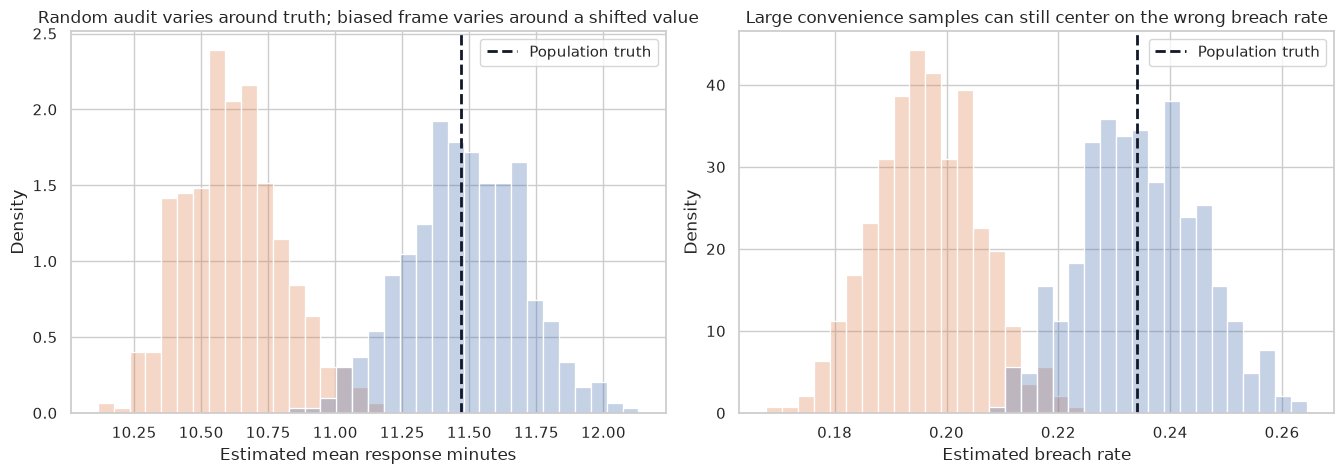

In [4]:
# Define helper functions and reusable utilities for this section.
coverage_heatmap = (
    population.groupby(["true_severity", "channel"], observed=True)["dashboard_logged"]
    .mean()
    .unstack()
    .reindex(index=severity_levels)
)
smart_display(coverage_heatmap)

def repeated_estimates(frame, sample_size, n_draws, label, seed):
    """
    Compute the repeated estimates quantity used in the statistical or decision-science workflow.
    
    Parameters:
        frame: Input DataFrame or data slice to summarize.
        sample_size: Sample size or group size used by the simulation, resampling, or inference step.
        n_draws: Sample size or group size used by the simulation, resampling, or inference step.
        label: Human-readable label attached to the returned summary.
        seed: Random seed used to make the simulation or resampling reproducible.
    
    Returns:
        A pandas DataFrame of repeated estimates from alternative data-source samples.
    
    Idea:
        Repeat the sampling process to show how frame choice or response mechanisms can systematically move estimates.
    """
    local_rng = np.random.default_rng(seed)
    idx = np.arange(len(frame))
    rows = []
    for draw in range(n_draws):
        chosen = local_rng.choice(idx, size=sample_size, replace=False)
        sample = frame.iloc[chosen]
        rows.append(
            {
                "source": label,
                "draw": draw,
                "mean_response_minutes": sample["true_response_minutes"].mean(),
                "breach_rate": sample["true_breach"].mean(),
            }
        )
    return pd.DataFrame(rows)


audit_draws = repeated_estimates(population, 1800, 500, "Random audit", seed=900)
dashboard_draws = repeated_estimates(dashboard_frame, 1800, 500, "Dashboard frame export", seed=901)
draws = pd.concat([audit_draws, dashboard_draws], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(13.6, 4.9))

sns.histplot(data=draws, x="mean_response_minutes", hue="source", bins=34, stat="density", common_norm=False, alpha=0.32, ax=axes[0])
axes[0].axvline(population["true_response_minutes"].mean(), color="#111827", linestyle="--", linewidth=2, label="Population truth")
axes[0].set_title("Random audit varies around truth; biased frame varies around a shifted value")
axes[0].set_xlabel("Estimated mean response minutes")
axes[0].legend()

sns.histplot(data=draws, x="breach_rate", hue="source", bins=34, stat="density", common_norm=False, alpha=0.32, ax=axes[1])
axes[1].axvline(population["true_breach"].mean(), color="#111827", linestyle="--", linewidth=2, label="Population truth")
axes[1].set_title("Large convenience samples can still center on the wrong breach rate")
axes[1].set_xlabel("Estimated breach rate")
axes[1].legend()

plt.tight_layout()
plt.show()

The histograms tell the core sampling-bias story. The random audit is noisy, but it is centered near the truth. The dashboard exports are also noisy, but around a shifted center because the frame itself underrepresents hard tickets.

This is exactly the difference between variance and bias. Repeated random sampling from the correct population creates fluctuation around the truth. Repeated sampling from the wrong frame creates fluctuation around the wrong answer.

## 4. Nonresponse Bias in Survey Feedback

Now we focus on the survey frame. Not every seller replies. More importantly, the probability of replying depends on dissatisfaction and priority status. That means the survey is not a random measurement device. It is a selective filter.

We will compare the survey respondent pool to the full population and inspect how response rates vary across true outcome strata.


In [5]:
# Build a summary table that supports the interpretation in the surrounding notes.
response_bias_table = pd.DataFrame(
    [
        {"quantity": "True dissatisfied share in population", "value": population["true_dissatisfied"].mean()},
        {"quantity": "True dissatisfied share among survey respondents", "value": survey_frame["true_dissatisfied"].mean()},
        {"quantity": "Mean true response minutes in population", "value": population["true_response_minutes"].mean()},
        {"quantity": "Mean true response minutes among survey respondents", "value": survey_frame["true_response_minutes"].mean()},
        {"quantity": "Observed dissatisfied share from returned survey scores", "value": (survey_frame["observed_satisfaction_score"] <= 2).mean()},
    ]
)
smart_display(response_bias_table)


,quantity,value
0,True dissatisfied share in population,0.045858
1,True dissatisfied share among survey respondents,0.098190
2,Mean true response minutes in population,11.467207
3,Mean true response minutes among survey respondents,12.509669
4,Observed dissatisfied share from returned survey scores,0.105268


The survey table is a nonresponse-bias warning. Respondents have higher true dissatisfaction and longer response times than the full population, so the returned survey scores do not behave like a neutral sample of all tickets.

This does not make survey data useless. It means the survey should be reported as respondent evidence, not population evidence, unless the analysis models or reweights the response mechanism. In decision terms, the apparent dissatisfaction rate is partly a service-quality signal and partly a measurement-process signal.


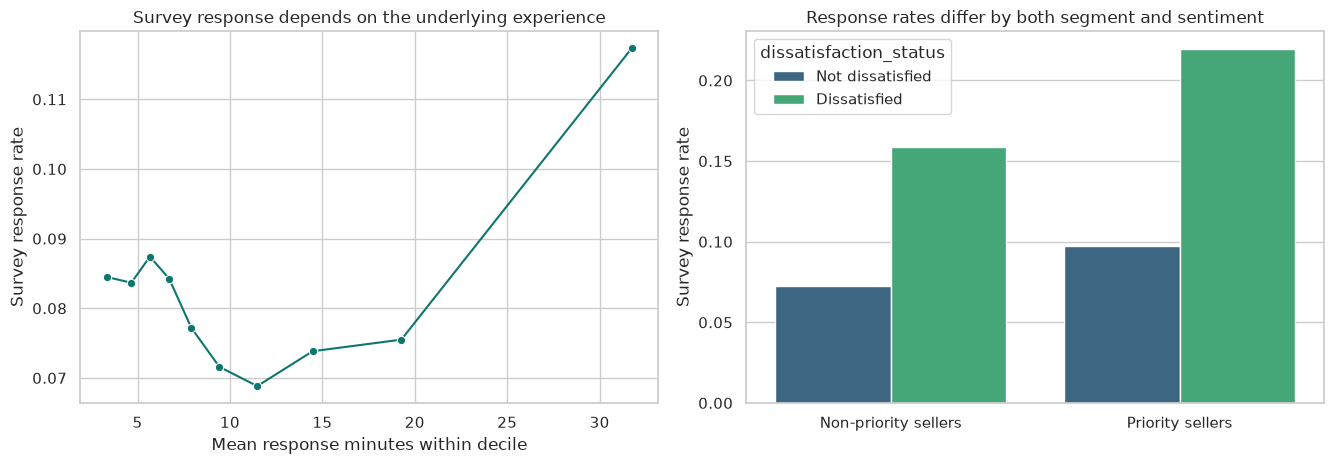

In [6]:
# Visualize the computed results so patterns and diagnostics are easier to interpret.
population["response_time_decile"] = pd.qcut(population["true_response_minutes"], q=10, duplicates="drop")
survey_rate_by_decile = (
    population.groupby("response_time_decile", observed=True)
    .agg(
        mean_response_minutes=("true_response_minutes", "mean"),
        survey_response_rate=("survey_responded", "mean"),
        dissatisfied_share=("true_dissatisfied", "mean"),
    )
    .reset_index(drop=True)
)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))

sns.lineplot(data=survey_rate_by_decile, x="mean_response_minutes", y="survey_response_rate", marker="o", color="#0f766e", ax=axes[0])
axes[0].set_title("Survey response depends on the underlying experience")
axes[0].set_xlabel("Mean response minutes within decile")
axes[0].set_ylabel("Survey response rate")

segment_response = (
    population.assign(segment=np.where(population["priority_contract"] == 1, "Priority sellers", "Non-priority sellers"))
    .groupby(["segment", "true_dissatisfied"], observed=True)["survey_responded"]
    .mean()
    .reset_index()
)
segment_response["dissatisfaction_status"] = np.where(segment_response["true_dissatisfied"] == 1, "Dissatisfied", "Not dissatisfied")

sns.barplot(data=segment_response, x="segment", y="survey_responded", hue="dissatisfaction_status", palette="viridis", ax=axes[1])
axes[1].set_title("Response rates differ by both segment and sentiment")
axes[1].set_xlabel("")
axes[1].set_ylabel("Survey response rate")

plt.tight_layout()
plt.show()


The survey is not simply smaller than the population. It is different from the population. The response-rate plots show that sellers with certain experiences are more likely to provide feedback, which shifts the distribution of observed survey outcomes.

This is what nonresponse bias means in practice. The central problem is informative missingness. Missing data can carry information about the outcome process.

## 5. Measurement Error and Label Dilution

Even when a ticket is observed, the recorded variables may not equal the true underlying state. Intake severity is a good example. Human or rule-based intake classification can blur boundaries, especially between medium, high, and urgent cases.

We compare the observed severity label against the true severity used in the simulation. The mismatch is a measurement problem, not a sampling problem.


In [7]:
# Build a summary table that supports the interpretation in the surrounding notes.
severity_confusion = pd.crosstab(population["true_severity"], population["observed_severity"], normalize="index").reindex(index=severity_levels, columns=severity_levels)
smart_display(severity_confusion)

true_high_risk = population["true_severity"].isin(["high", "urgent"])
observed_high_risk = population["observed_severity"].isin(["high", "urgent"])

measurement_table = pd.DataFrame(
    [
        {"quantity": "Share truly high-risk (high or urgent)", "value": true_high_risk.mean()},
        {"quantity": "Share observed as high-risk", "value": observed_high_risk.mean()},
        {"quantity": "Breach rate among truly high-risk tickets", "value": population.loc[true_high_risk, "true_breach"].mean()},
        {"quantity": "Breach rate among observed high-risk tickets", "value": population.loc[observed_high_risk, "true_breach"].mean()},
        {"quantity": "Recall of observed high-risk for true high-risk tickets", "value": observed_high_risk[true_high_risk].mean()},
        {"quantity": "Precision of observed high-risk label", "value": true_high_risk[observed_high_risk].mean()},
    ]
)
smart_display(measurement_table)


observed_severity,low,medium,high,urgent
true_severity,,,,
low,0.879,0.101,0.019,0.000
medium,0.079,0.743,0.158,0.020
high,0.020,0.161,0.695,0.124
urgent,0.000,0.083,0.232,0.686


,quantity,value
0,Share truly high-risk (high or urgent),0.392750
1,Share observed as high-risk,0.398075
2,Breach rate among truly high-risk tickets,0.554954
3,Breach rate among observed high-risk tickets,0.492621
4,Recall of observed high-risk for true high-risk tickets,0.868831
5,Precision of observed high-risk label,0.857209


The measurement table separates true severity from the label the analyst actually receives. Misclassification pushes some difficult tickets into easier-looking categories and some easier tickets into harder-looking categories, which blurs the relationship between severity and response risk.

For teaching, this is the key distinction between a noisy covariate and a noisy outcome. A mislabeled feature can distort subgroup summaries, model coefficients, and operational triage rules even when the outcome itself is measured accurately.


,breach_rate_by_true_severity,breach_rate_by_observed_severity
true_severity,,
low,0.011090,0.017746
medium,0.043907,0.111038
high,0.317861,0.350295
urgent,0.785284,0.691239


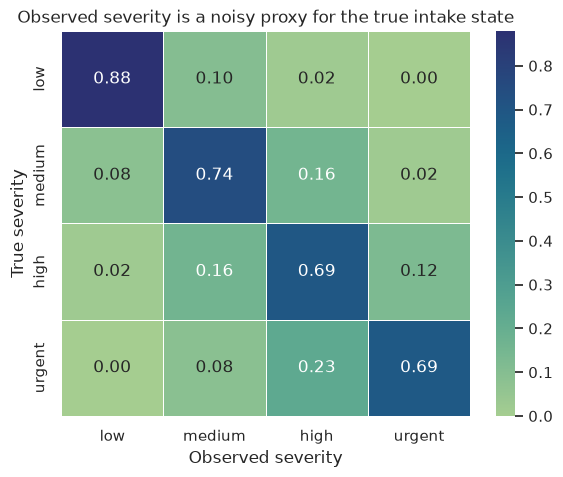

In [8]:
# Visualize the computed results so patterns and diagnostics are easier to interpret.
severity_risk_table = (
    population.groupby("true_severity", observed=True)["true_breach"]
    .mean()
    .rename("breach_rate_by_true_severity")
    .to_frame()
    .join(
        population.groupby("observed_severity", observed=True)["true_breach"]
        .mean()
        .rename("breach_rate_by_observed_severity")
        .rename_axis("true_severity")
    )
)
smart_display(severity_risk_table)

plt.figure(figsize=(6.6, 5.0))
sns.heatmap(severity_confusion, annot=True, fmt=".2f", cmap="crest", linewidths=0.5)
plt.title("Observed severity is a noisy proxy for the true intake state")
plt.xlabel("Observed severity")
plt.ylabel("True severity")
plt.show()


Measurement error often dilutes contrast. When urgent tickets are partially mislabeled as merely high, and high tickets are partially mislabeled as medium, the observed high-risk group becomes a noisier blend. That lowers the apparent distinctiveness of the group even if the underlying risk difference is real.

This matters because downstream models and operational rules inherit the quality of their labels. If the label itself is blurred, the resulting analysis is also blurred.

## 6. One Decision, Many Answers

Suppose leadership asks whether priority sellers are receiving acceptable service. We will judge this using three criteria:

- mean response minutes;
- breach rate;
- dissatisfied-share estimate.

Different data sources will now produce different answers because the data streams embody different biases.


In [9]:
# Build a summary table that supports the interpretation in the surrounding notes.
priority_population = population.loc[population["priority_contract"] == 1]
priority_audit = audit_sample.loc[audit_sample["priority_contract"] == 1]
priority_dashboard = dashboard_export.loc[dashboard_export["priority_contract"] == 1]
priority_survey = survey_frame.loc[survey_frame["priority_contract"] == 1]

decision_table = pd.DataFrame(
    [
        {
            "source": "Population truth",
            "mean_response_minutes": priority_population["true_response_minutes"].mean(),
            "breach_rate": priority_population["true_breach"].mean(),
            "dissatisfied_share_estimate": priority_population["true_dissatisfied"].mean(),
        },
        {
            "source": "Random audit",
            "mean_response_minutes": priority_audit["true_response_minutes"].mean(),
            "breach_rate": priority_audit["true_breach"].mean(),
            "dissatisfied_share_estimate": priority_audit["true_dissatisfied"].mean(),
        },
        {
            "source": "Dashboard export",
            "mean_response_minutes": priority_dashboard["true_response_minutes"].mean(),
            "breach_rate": priority_dashboard["true_breach"].mean(),
            "dissatisfied_share_estimate": priority_dashboard["true_dissatisfied"].mean(),
        },
        {
            "source": "Survey respondents",
            "mean_response_minutes": priority_survey["true_response_minutes"].mean(),
            "breach_rate": priority_survey["true_breach"].mean(),
            "dissatisfied_share_estimate": (priority_survey["observed_satisfaction_score"] <= 2).mean(),
        },
    ]
)
smart_display(decision_table)


,source,mean_response_minutes,breach_rate,dissatisfied_share_estimate
0,Population truth,13.169,0.309,0.059
1,Random audit,13.589,0.329,0.066
2,Dashboard export,12.806,0.296,0.065
3,Survey respondents,14.293,0.322,0.131


The repeated-estimate summary separates accuracy from stability. The random audit has sampling variation, but its center remains close to the population target. The biased frame can look stable across repeated samples while staying systematically away from the truth.

This is why a large, convenient dataset can be less trustworthy than a smaller audit. Precision around the wrong target is not evidence quality. The first question is whether the data-generating and collection process points at the decision target.


In [10]:
# Build a summary table that supports the interpretation in the surrounding notes.
truth = decision_table.loc[decision_table["source"] == "Population truth"].iloc[0]
bias_table = decision_table.copy()
for col in ["mean_response_minutes", "breach_rate", "dissatisfied_share_estimate"]:
    bias_table[f"bias_in_{col}"] = bias_table[col] - truth[col]
smart_display(bias_table)


,source,mean_response_minutes,breach_rate,dissatisfied_share_estimate,bias_in_mean_response_minutes,bias_in_breach_rate,bias_in_dissatisfied_share_estimate
0,Population truth,13.169245,0.309230,0.058615,0.000000,0.000000,0.000000
1,Random audit,13.589467,0.329238,0.066339,0.420222,0.020009,0.007724
2,Dashboard export,12.806114,0.296020,0.064677,-0.363131,-0.013210,0.006061
3,Survey respondents,14.292604,0.322010,0.131023,1.123359,0.012781,0.072407


The decision table shows why data provenance matters. The dashboard export typically looks too optimistic on response and breach because difficult tickets are undercaptured. The survey respondents typically look too negative on dissatisfaction because unhappy users are more motivated to answer. The random audit is imperfect and tends to stay much closer to the population truth because its error is mostly random.

This is the right way to talk about bias professionally. We do not simply say that one source is good and another is bad. We identify the direction in which each source is likely to tilt the decision.

## 7. A Practical Dataset-Credibility Checklist

Bias diagnosis should end in workflow guidance as well as criticism. Before trusting an operational dataset, analysts should ask a small number of credibility questions.


| Diagnostic Question | Why It Matters |
|---|---|
| What population is the dataset intended to represent? | Without a target population, representativeness cannot be evaluated |
| Which units are systematically missing from the frame? | Coverage bias can shift estimates before sampling even starts |
| Is response or participation related to the outcome of interest? | If yes, complete-case summaries can be biased |
| Which variables are measured directly and which are noisy proxies? | Label error and proxy mismatch can dilute true signal |
| Do benchmark audits exist? | Small principled audits are often more informative than large convenience extracts |
| Can bias direction be anticipated? | Knowing whether a source is optimistic or pessimistic sharpens decision language |


In [11]:
# Build a summary table that supports the interpretation in the surrounding notes.
credibility_flags = pd.DataFrame(
    [
        {
            "source": "Dashboard frame",
            "coverage_gap_vs_population": 1 - population["dashboard_logged"].mean(),
            "urgent_underrepresentation": source_summary.loc["Target population", "share_urgent"] - source_summary.loc["Dashboard export", "share_urgent"],
            "phone_underrepresentation": source_summary.loc["Target population", "share_phone"] - source_summary.loc["Dashboard export", "share_phone"],
        },
        {
            "source": "Survey respondents",
            "coverage_gap_vs_population": 1 - population["survey_responded"].mean(),
            "urgent_underrepresentation": source_summary.loc["Target population", "share_urgent"] - source_summary.loc["Survey respondents", "share_urgent"],
            "phone_underrepresentation": source_summary.loc["Target population", "share_phone"] - source_summary.loc["Survey respondents", "share_phone"],
        },
    ]
)
smart_display(credibility_flags)


,source,coverage_gap_vs_population,urgent_underrepresentation,phone_underrepresentation
0,Dashboard frame,0.195,0.044,0.061
1,Survey respondents,0.918,-0.029,-0.018


The final bias summary is a reporting checklist for data credibility. Coverage, response, and measurement problems do not merely add noise. They can each move the estimand in a different direction and make a clean-looking dashboard disagree with the population quantity leadership actually cares about.

The practical implication is that recommendations should name the data source and its failure mode. A decision memo should distinguish “what the export says,” “what the audit suggests,” and “what remains uncertain because of labeling or response behavior.”


## 8. Real-Data Companion: NYC 311 Reporting Channels and Coverage

The synthetic examples above make sampling and measurement bias visible because we know the target population. Real service systems are harder because the target population is usually not directly observed. NYC 311 records reported service requests, not all underlying city problems. That distinction matters: reporting behavior, channel access, geography, language, awareness, and agency workflows can all influence what appears in the data.

The dataset contains request-level records with complaint type, agency, borough, reporting channel, creation and close times, status, and location fields. Those fields are operationally rich, but they are also products of a reporting system. A mobile-app request, a phone call, and an online submission may not represent the same slice of residents or the same kinds of service needs.

This companion starts with credibility before policy. Do observed requests look similar across reporting channels and geography, or would a channel-heavy extract change what we think the system is doing? This is a real-data version of the sampling-frame problem: the table can be accurate about reported requests while still being incomplete evidence about actual service need.

For clarity, the unit is a reported service request. The main outcomes are observed request composition, close-time timing, and channel mix across geography. The experiment is a coverage audit: it asks whether the observed request data are stable across reporting mechanisms or whether the data source itself shapes the conclusion.

Data source: [NYC Open Data 311 Service Requests](https://data.cityofnewyork.us/api/views/erm2-nwe9).

,open_data_channel_type,requests,missing_borough_rate,median_resolution_hours,p90_resolution_hours
0,ONLINE,2517,0.000,1.055,4.580
1,MOBILE,1473,0.001,1.220,4.498
2,UNKNOWN,516,0.000,0.000,4.249
3,PHONE,491,0.002,1.113,7.150


,open_data_channel_type,complaint_type,requests
6,MOBILE,Illegal Parking,718
9,MOBILE,Noise - Street/Sidewalk,206
1,MOBILE,Blocked Driveway,148
35,ONLINE,Illegal Parking,782
44,ONLINE,Noise - Residential,444
19,ONLINE,Blocked Driveway,321
83,PHONE,Illegal Parking,83
87,PHONE,Noise - Residential,61
105,PHONE,Water System,55
116,UNKNOWN,General Construction/Plumbing,124


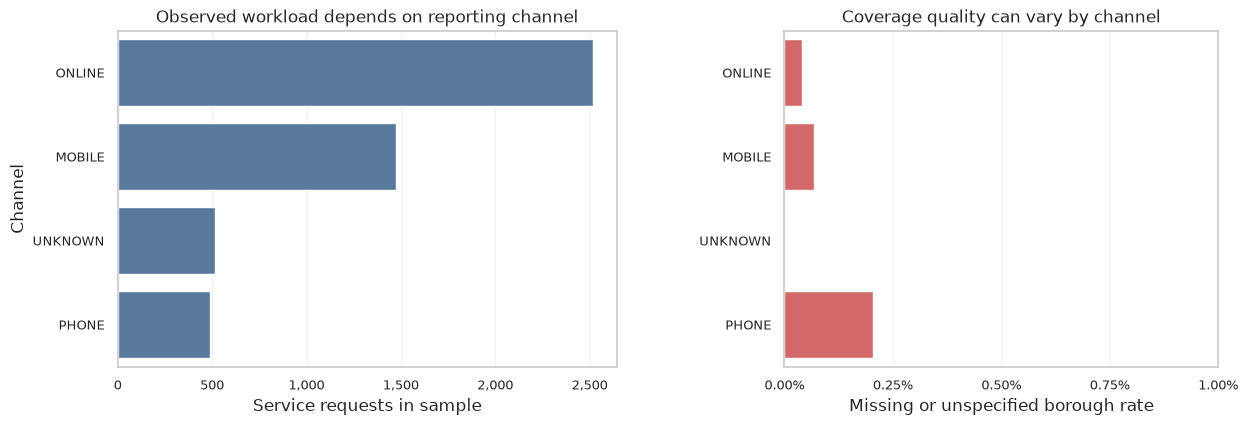

In [12]:
from pathlib import Path
import sys


def _find_project_root(start=Path.cwd()):
    """
    Locate the portfolio root so shared notebook helpers import reliably.
    
    Parameters:
        start: Starting path for the upward project-root search.
    
    Returns:
        A `Path` pointing to the nearest portfolio root that contains `notebooks/_shared`; if no such parent is found, the original starting path is returned.
    """

    for candidate in [start, *start.parents]:
        if (candidate / "notebooks" / "_shared").exists():
            return candidate
    return start


PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from notebooks._shared.real_data import fetch_nyc_311, optional_data_note

RUN_REAL_DATA_COMPANION = True

if RUN_REAL_DATA_COMPANION:
    nyc_311 = fetch_nyc_311(limit=7_500, start_date="2025-01-01")
    nyc_311["resolution_hours"] = (
        nyc_311["closed_date"] - nyc_311["created_date"]
    ).dt.total_seconds() / 3600
    nyc_311 = nyc_311.query("0 <= resolution_hours <= 720").copy()
    nyc_311["missing_borough"] = nyc_311["borough"].isna() | nyc_311["borough"].eq("Unspecified")

    channel_summary = (
        nyc_311.groupby("open_data_channel_type", dropna=False)
        .agg(
            requests=("unique_key", "count"),
            missing_borough_rate=("missing_borough", "mean"),
            median_resolution_hours=("resolution_hours", "median"),
            p90_resolution_hours=("resolution_hours", lambda s: s.quantile(0.90)),
        )
        .sort_values("requests", ascending=False)
        .reset_index()
    )

    top_complaints_by_channel = (
        nyc_311.groupby(["open_data_channel_type", "complaint_type"], dropna=False)
        .size()
        .rename("requests")
        .reset_index()
        .sort_values(["open_data_channel_type", "requests"], ascending=[True, False])
        .groupby("open_data_channel_type")
        .head(3)
    )

    smart_display(channel_summary.round(3))
    smart_display(top_complaints_by_channel)

    from matplotlib.ticker import MaxNLocator, PercentFormatter, StrMethodFormatter

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(14.2, 4.8),
        gridspec_kw={"width_ratios": [1.15, 1.0]},
    )
    sns.barplot(
        data=channel_summary,
        y="open_data_channel_type",
        x="requests",
        ax=axes[0],
        color="#4C78A8",
    )
    axes[0].set_title("Observed workload depends on reporting channel")
    axes[0].set_xlabel("Service requests in sample")
    axes[0].set_ylabel("Channel")
    axes[0].xaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))

    sns.barplot(
        data=channel_summary,
        y="open_data_channel_type",
        x="missing_borough_rate",
        ax=axes[1],
        color="#E45756",
    )
    max_missing_rate = channel_summary["missing_borough_rate"].max()
    axes[1].set_xlim(0, max(max_missing_rate * 1.25, 0.01))
    axes[1].xaxis.set_major_locator(MaxNLocator(nbins=4, min_n_ticks=3))
    axes[1].xaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=2))
    axes[1].set_title("Coverage quality can vary by channel")
    axes[1].set_xlabel("Missing or unspecified borough rate")
    axes[1].set_ylabel("")

    for ax in axes:
        ax.tick_params(axis="x", labelsize=9)
        ax.tick_params(axis="y", labelsize=9)
        ax.grid(axis="x", alpha=0.25)

    fig.subplots_adjust(wspace=0.36, bottom=0.18)
    plt.show()
else:
    optional_data_note(
        "NYC 311 Service Requests",
        "https://data.cityofnewyork.us/api/views/erm2-nwe9",
        "RUN_REAL_DATA_COMPANION",
    )

This companion makes the same point as the synthetic bias examples, but with fewer guarantees. A 311 extract is an observed reporting system, not a random sample of all problems. If channel mix or location completeness changes, the apparent service story can change too. This is why data-source credibility belongs near the beginning of an analysis, not as a footnote after modeling.

## Wrap-Up

We saw how bias can enter long before estimation, testing, or modeling:

1. Coverage bias changes which units are even visible.
2. Convenience samples from biased frames stay biased, even when repeated and even when large.
3. Nonresponse bias arises when participation depends on the underlying experience.
4. Measurement error blurs labels and weakens group contrasts.
5. Different operational data sources can tilt a decision in different directions.
6. A random audit may be noisy, but it can still be more trustworthy than a large convenience extract.

The deeper lesson is simple: if the data-collection mechanism is distorted, downstream statistical sophistication cannot fully rescue the answer. The next notebooks will build on this by turning from bias in data collection to the properties of estimators themselves.


## References

- Brown, R. V. (1967). *Evaluation of total survey error*. *Journal of Marketing Research*, 4(2), 117-127. [https://doi.org/10.1177/002224376700400201](https://doi.org/10.1177/002224376700400201)
- Groves, R. M. (2006). *Nonresponse rates and nonresponse bias in household surveys*. *Public Opinion Quarterly*, 70(5), 646-675. [https://doi.org/10.1093/poq/nfl033](https://doi.org/10.1093/poq/nfl033)
- Olson, K. (2006). *Survey participation, nonresponse bias, measurement error bias, and total bias*. *Public Opinion Quarterly*, 70(5), 737-758. [https://doi.org/10.1093/poq/nfl038](https://doi.org/10.1093/poq/nfl038)
- Stefanski, L. A. (2000). *Measurement error models*. *Journal of the American Statistical Association*, 95(452), 1353-1358. [https://doi.org/10.1080/01621459.2000.10474347](https://doi.org/10.1080/01621459.2000.10474347)
- Tukey, J. W. (1962). *The future of data analysis*. *The Annals of Mathematical Statistics*, 33(1), 1-67. [https://doi.org/10.1214/aoms/1177704711](https://doi.org/10.1214/aoms/1177704711)
